Matplotlib is building the font cache; this may take a moment.



1) DESCRIPTIVE STATISTICS
Data: [10. 12. 15. 18. 20. 22. 25.]
Mean: 17.4286
Median: 18.0000
Mode: 10.0000
Variance (population): 25.1020
Std Dev (population): 5.0102
Variance (sample): 29.2857
Std Dev (sample): 5.4116
Range: 15.0000
Q1: 13.5000, Q3: 21.0000, IQR: 7.5000

2) PROBABILITY DISTRIBUTIONS
Binomial Distribution:
 X ~ Bin(n=10, p=0.5)
 P(X=5) = 0.246094
 Mean = np = 5.0000
 Variance = np(1-p) = 2.5000

Poisson Distribution:
 X ~ Pois(λ=3)
 P(X=2) = 0.224042
 Mean = λ = 3.0000
 Variance = λ = 3.0000

Normal Distribution Plot (PDF)


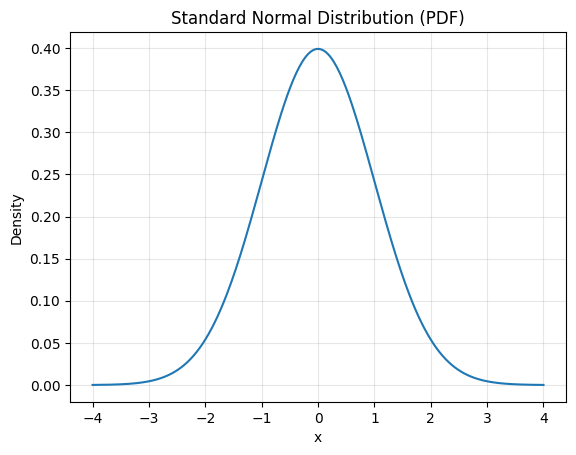


3) EMPIRICAL RULE (68–95–99.7)
Mean (μ) = 17.4286, Std (σ) = 5.0102
Proportion within 1σ: 0.5714 (rule-of-thumb ~0.68)
Proportion within 2σ: 1.0000 (rule-of-thumb ~0.95)
Proportion within 3σ: 1.0000 (rule-of-thumb ~0.997)

4) STATISTICAL INFERENCE — One-sample test (t-test)
H0: mean = 15
t-statistic: 1.187332
p-value: 0.279967
At alpha=0.05, decision: FAIL TO REJECT H0

5) CONFIDENCE INTERVAL (Mean)
95% CI for mean: (12.4237, 22.4335)

6) CORRELATION
x: [1. 2. 3. 4. 5.]
y: [ 2.  4.  6.  8. 10.]
Pearson r: 1.000000, p-value: 0.000000
Spearman rho: 1.000000, p-value: 0.000000

7) LINEAR REGRESSION + RESIDUALS + R^2
Model: y = β0 + β1 x
β0 (intercept): 0.000000
β1 (slope): 2.000000
Predictions: [ 2.  4.  6.  8. 10.]
Residuals: [0. 0. 0. 0. 0.]
R^2: 1.000000


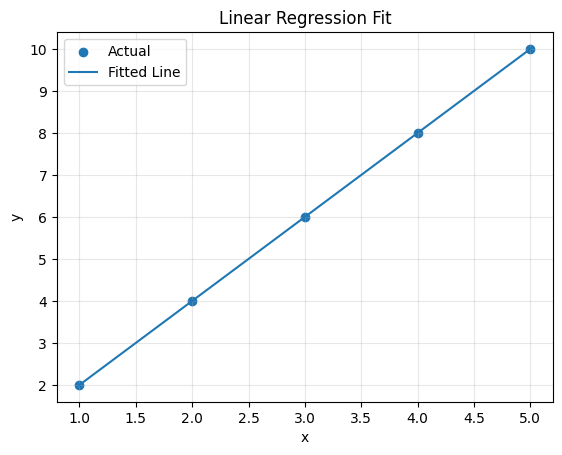


8) OUTLIER DETECTION (Z-score)
Z-scores: [-1.4827 -1.0835 -0.4847  0.1141  0.5132  0.9124  1.5112]
Outliers (|z| > 3): None

9) DATA VISUALIZATION — Histogram + Boxplot


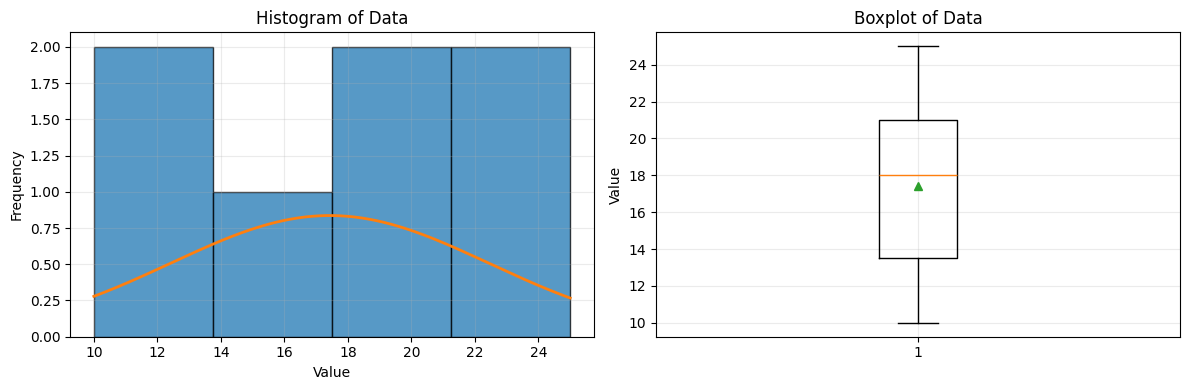


DONE ✅ — Script ran successfully.


In [1]:
# ============================================
# STATISTICS CHEATSHEET TRAINING — MERGED SCRIPT
# Covers:
# 1) Descriptive Stats
# 2) Binomial / Poisson / Normal
# 3) Empirical Rule (68-95-99.7)
# 4) Statistical Inference (t-test as practical)
# 5) Confidence Interval
# 6) Correlation
# 7) Linear Regression, Residuals, R^2
# 8) Outlier Detection (Z-score)
# 9) Histogram + Boxplot (NEW ✅)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

# ----------------------------
# Utility printing
# ----------------------------
def section(title):
 print("\n" + "=" * 60)
 print(title)
 print("=" * 60)

np.random.seed(42)

# ----------------------------
# Sample data (you can replace this)
# ----------------------------
data = np.array([10, 12, 15, 18, 20, 22, 25], dtype=float)

# For correlation/regression demo
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)

# =========================================================
# 1) DESCRIPTIVE STATISTICS
# =========================================================
section("1) DESCRIPTIVE STATISTICS")

mean = np.mean(data)
median = np.median(data)

# Mode: stats.mode returns an object; keepdims=False helps newer scipy
mode_res = stats.mode(data, keepdims=True)
mode = mode_res.mode[0]

variance_pop = np.var(data) # population variance
std_pop = np.std(data) # population std
variance_samp = np.var(data, ddof=1) # sample variance
std_samp = np.std(data, ddof=1) # sample std

data_range = np.max(data) - np.min(data)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

print(f"Data: {data}")
print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Mode: {mode:.4f}")
print(f"Variance (population): {variance_pop:.4f}")
print(f"Std Dev (population): {std_pop:.4f}")
print(f"Variance (sample): {variance_samp:.4f}")
print(f"Std Dev (sample): {std_samp:.4f}")
print(f"Range: {data_range:.4f}")
print(f"Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")

# =========================================================
# 2) PROBABILITY DISTRIBUTIONS
# =========================================================
section("2) PROBABILITY DISTRIBUTIONS")

# --- Binomial ---
n = 10
p = 0.5
k = 5
binom_prob = stats.binom.pmf(k, n, p)
binom_mean = n * p
binom_var = n * p * (1 - p)

print("Binomial Distribution:")
print(f" X ~ Bin(n={n}, p={p})")
print(f" P(X={k}) = {binom_prob:.6f}")
print(f" Mean = np = {binom_mean:.4f}")
print(f" Variance = np(1-p) = {binom_var:.4f}")

# --- Poisson ---
lam = 3
k2 = 2
poisson_prob = stats.poisson.pmf(k2, lam)
print("\nPoisson Distribution:")
print(f" X ~ Pois(λ={lam})")
print(f" P(X={k2}) = {poisson_prob:.6f}")
print(f" Mean = λ = {lam:.4f}")
print(f" Variance = λ = {lam:.4f}")

# --- Normal ---
section("Normal Distribution Plot (PDF)")
xx = np.linspace(-4, 4, 300)
yy = stats.norm.pdf(xx, loc=0, scale=1)

plt.figure()
plt.plot(xx, yy)
plt.title("Standard Normal Distribution (PDF)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 3) EMPIRICAL RULE (68-95-99.7)
# =========================================================
section("3) EMPIRICAL RULE (68–95–99.7)")

mu = mean
sigma = std_pop if std_pop != 0 else 1e-9

within_1sigma = np.mean((data > mu - sigma) & (data < mu + sigma))
within_2sigma = np.mean((data > mu - 2*sigma) & (data < mu + 2*sigma))
within_3sigma = np.mean((data > mu - 3*sigma) & (data < mu + 3*sigma))

print(f"Mean (μ) = {mu:.4f}, Std (σ) = {sigma:.4f}")
print(f"Proportion within 1σ: {within_1sigma:.4f} (rule-of-thumb ~0.68)")
print(f"Proportion within 2σ: {within_2sigma:.4f} (rule-of-thumb ~0.95)")
print(f"Proportion within 3σ: {within_3sigma:.4f} (rule-of-thumb ~0.997)")

# =========================================================
# 4) STATISTICAL INFERENCE (Practical version: one-sample t-test)
# Cheatsheet shows Z; in practice, σ unknown => t-test is standard.
# =========================================================
section("4) STATISTICAL INFERENCE — One-sample test (t-test)")

popmean_h0 = 15 # Hypothesized mean
t_stat, p_value = stats.ttest_1samp(data, popmean=popmean_h0)

print(f"H0: mean = {popmean_h0}")
print(f"t-statistic: {t_stat:.6f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05
decision = "REJECT H0" if p_value < alpha else "FAIL TO REJECT H0"
print(f"At alpha={alpha}, decision: {decision}")

# =========================================================
# 5) CONFIDENCE INTERVAL (Mean)
# =========================================================
section("5) CONFIDENCE INTERVAL (Mean)")

confidence = 0.95
n_data = len(data)
sample_mean = np.mean(data)
sem = stats.sem(data) # standard error of mean
ci_low, ci_high = stats.t.interval(confidence, df=n_data-1, loc=sample_mean, scale=sem)

print(f"{int(confidence*100)}% CI for mean: ({ci_low:.4f}, {ci_high:.4f})")

# =========================================================
# 6) CORRELATION
# =========================================================
section("6) CORRELATION")

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"x: {x}")
print(f"y: {y}")
print(f"Pearson r: {pearson_r:.6f}, p-value: {pearson_p:.6f}")
print(f"Spearman rho: {spearman_r:.6f}, p-value: {spearman_p:.6f}")

# =========================================================
# 7) LINEAR REGRESSION + RESIDUALS + R^2
# =========================================================
section("7) LINEAR REGRESSION + RESIDUALS + R^2")

X = x.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)

beta0 = model.intercept_
beta1 = model.coef_[0]
y_pred = model.predict(X)
residuals = y - y_pred
r2 = model.score(X, y)

print(f"Model: y = β0 + β1 x")
print(f"β0 (intercept): {beta0:.6f}")
print(f"β1 (slope): {beta1:.6f}")
print(f"Predictions: {y_pred}")
print(f"Residuals: {residuals}")
print(f"R^2: {r2:.6f}")

# Plot regression line
plt.figure()
plt.scatter(x, y, label="Actual")
plt.plot(x, y_pred, label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 8) OUTLIER DETECTION (Z-score rule)
# =========================================================
section("8) OUTLIER DETECTION (Z-score)")

z_scores = (data - mu) / sigma
outliers = data[np.abs(z_scores) > 3]

print(f"Z-scores: {np.round(z_scores, 4)}")
if len(outliers) == 0:
 print("Outliers (|z| > 3): None")
else:
 print(f"Outliers (|z| > 3): {outliers}")

# =========================================================
# 9) HISTOGRAM + BOXPLOT (NEW ✅)
# =========================================================
section("9) DATA VISUALIZATION — Histogram + Boxplot")

plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(data, bins="auto", edgecolor="black", alpha=0.75)
plt.title("Histogram of Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.25)

# Optional KDE overlay (smooth curve) using normal fit
# (works fine even without seaborn)
x_line = np.linspace(data.min(), data.max(), 200)
pdf_line = stats.norm.pdf(x_line, loc=mean, scale=std_pop if std_pop != 0 else 1e-9)
# Scale PDF to histogram-like height (roughly) for visual overlay
pdf_line_scaled = pdf_line * len(data) * (data.max() - data.min()) / 10
plt.plot(x_line, pdf_line_scaled, linewidth=2)

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(data, vert=True, showmeans=True)
plt.title("Boxplot of Data")
plt.ylabel("Value")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


section("DONE ✅ — Script ran successfully.")

